# Q-Learning — An Illustrated Tour

> Learn the optimal **action-value** $Q^*(s, a)$ by trial and error. No model of the environment, no neural net — just a table updated by the Bellman equation.

---

**What we cover:**
- A 5×7 grid-world with one trap and one goal
- Bellman optimality: $Q^*(s, a) = r + \gamma \max_{a'} Q^*(s', a')$
- $\varepsilon$-greedy exploration
- Watching the value map and policy emerge over episodes
- Effect of the discount factor $\gamma$

## The picture — agent ↔ environment loop, update a table of Q(s,a)

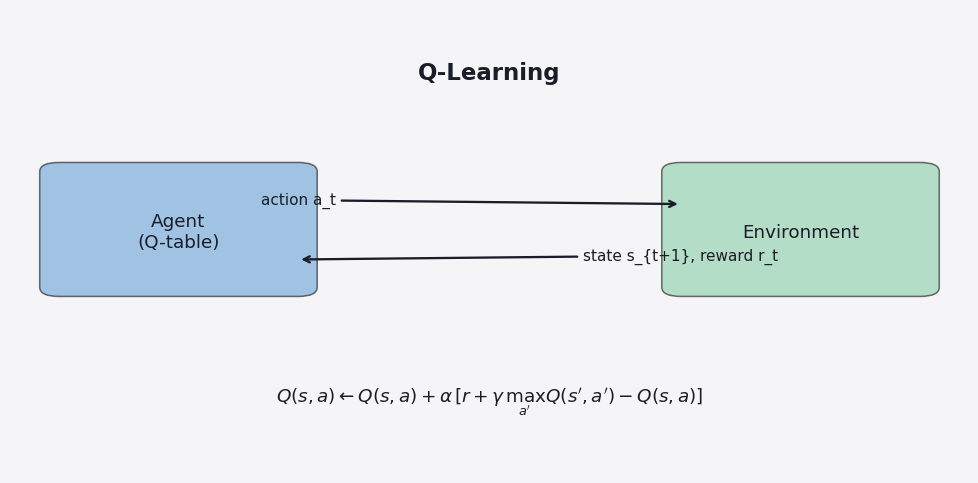

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(9, 4.5)); ax.axis('off')
ax.add_patch(FancyBboxPatch((0.05, 0.4), 0.25, 0.25, boxstyle='round,pad=0.02',
                            facecolor=P[0], alpha=0.55))
ax.text(0.175, 0.52, 'Agent\n(Q-table)', ha='center', va='center', fontsize=12)
ax.add_patch(FancyBboxPatch((0.7, 0.4), 0.25, 0.25, boxstyle='round,pad=0.02',
                            facecolor=P[3], alpha=0.55))
ax.text(0.825, 0.52, 'Environment', ha='center', va='center', fontsize=12)
ax.annotate('action a_t', xy=(0.7, 0.58), xytext=(0.30, 0.58),
            arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.5),
            fontsize=10, ha='center')
ax.annotate('state s_{t+1}, reward r_t', xy=(0.30, 0.46), xytext=(0.7, 0.46),
            arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.5),
            fontsize=10, ha='center')
ax.text(0.5, 0.15, r"$Q(s,a) \leftarrow Q(s,a) + \alpha\,[r + \gamma\,\max_{a'} Q(s',a') - Q(s,a)]$",
        ha='center', fontsize=12)
ax.text(0.5, 0.85, 'Q-Learning', ha='center', fontsize=15, weight='bold')
plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':17,'axes.labelsize':13,
    'xtick.labelsize':11,'ytick.labelsize':11,'legend.fontsize':11,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':120,
}
plt.rcParams.update(PLT_STYLE)
C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'

# --- grid world ---------------------------------------------------
H, W = 5, 7
GOAL = (4, 6); TRAP = (2, 3); START = (0, 0)
ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}    # up,down,left,right
ARROWS = {0:'↑', 1:'↓', 2:'←', 3:'→'}

def step(s, a):
    dr, dc = ACTIONS[a]
    nr, nc = s[0]+dr, s[1]+dc
    if not (0 <= nr < H and 0 <= nc < W): nr, nc = s
    s2 = (nr, nc)
    if s2 == GOAL: return s2, 1.0, True
    if s2 == TRAP: return s2, -1.0, True
    return s2, -0.02, False
print('Grid world built.')

Grid world built.


---
## Bellman Update

$$Q(s, a) \leftarrow Q(s, a) + \alpha \bigl[r + \gamma \max_{a'} Q(s', a') - Q(s, a)\bigr].$$

Behaviour policy: $\varepsilon$-greedy on $Q$ — with prob $\varepsilon$ take a random action, else $\arg\max_a Q(s,a)$. Run many episodes; the table converges to $Q^*$.

In [3]:
def train(n_episodes, alpha=0.5, gamma=0.95, eps=0.2, seed=0, snapshots=None):
    rng = np.random.default_rng(seed)
    Q = np.zeros((H, W, 4))
    snaps = {}
    rewards = []
    for ep in range(n_episodes):
        s = START; total = 0.0
        for _ in range(200):
            a = rng.integers(0,4) if rng.random() < eps else int(np.argmax(Q[s[0], s[1]]))
            s2, r, done = step(s, a)
            target = r + (0 if done else gamma * Q[s2[0], s2[1]].max())
            Q[s[0], s[1], a] += alpha * (target - Q[s[0], s[1], a])
            s = s2; total += r
            if done: break
        rewards.append(total)
        if snapshots and ep+1 in snapshots:
            snaps[ep+1] = Q.copy()
    return Q, rewards, snaps

snaps_at = [5, 30, 100, 500]
Q_final, rewards, snaps = train(500, snapshots=snaps_at)

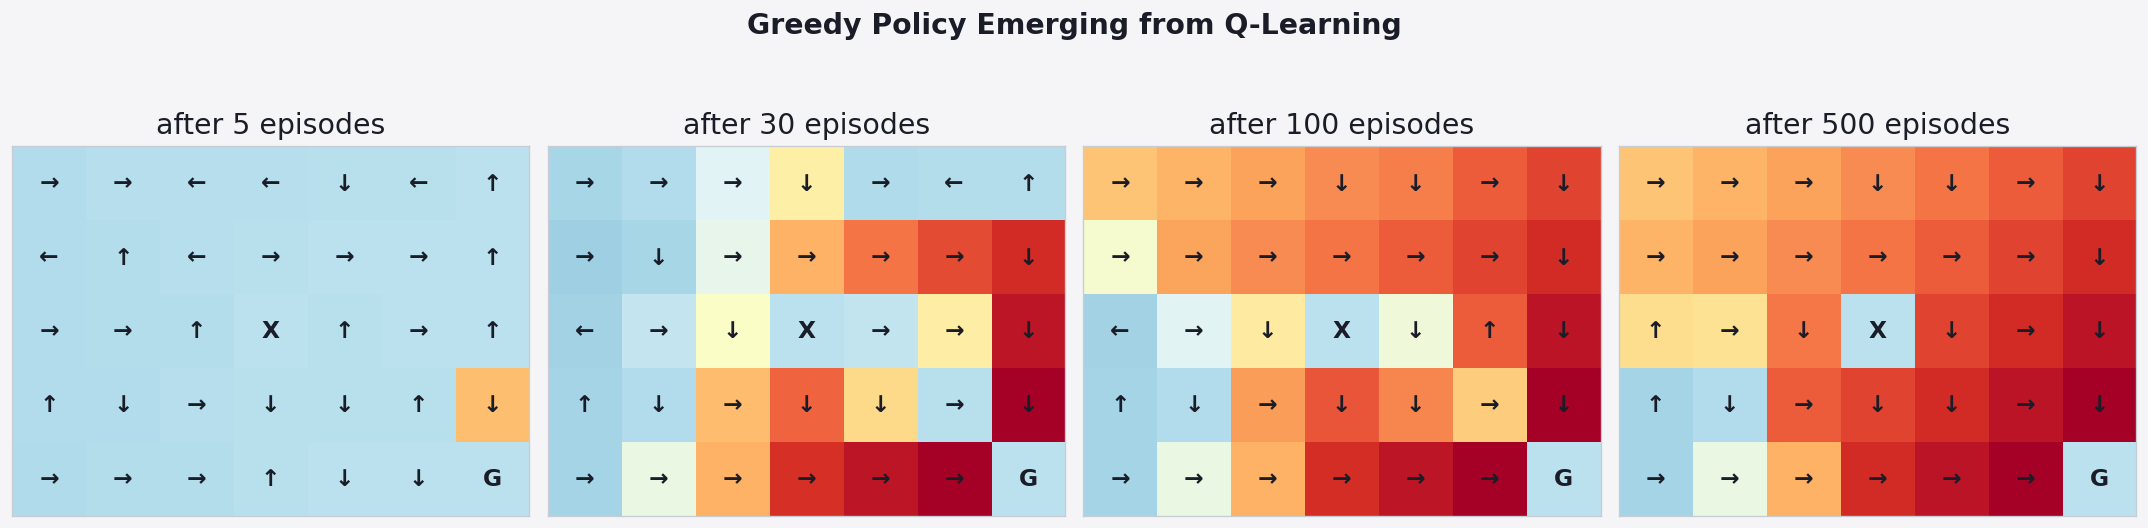

In [4]:
def plot_policy(ax, Q, title):
    V = Q.max(-1)
    im = ax.imshow(V, cmap='RdYlBu_r', vmin=-0.5, vmax=1.0)
    for r in range(H):
        for c in range(W):
            if (r, c) == GOAL: ax.text(c, r, 'G', ha='center', va='center', color='#1a1d27', fontsize=14, fontweight='bold')
            elif (r, c) == TRAP: ax.text(c, r, 'X', ha='center', va='center', color='#1a1d27', fontsize=14, fontweight='bold')
            else: ax.text(c, r, ARROWS[int(np.argmax(Q[r, c]))], ha='center', va='center', color='#1a1d27', fontsize=14, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, pad=8)
    return im

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, ep in zip(axes, snaps_at):
    plot_policy(ax, snaps[ep], f'after {ep} episodes')
fig.suptitle('Greedy Policy Emerging from Q-Learning', fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

---
## Reward Curve

Episode return rises and the variance shrinks as the policy commits.

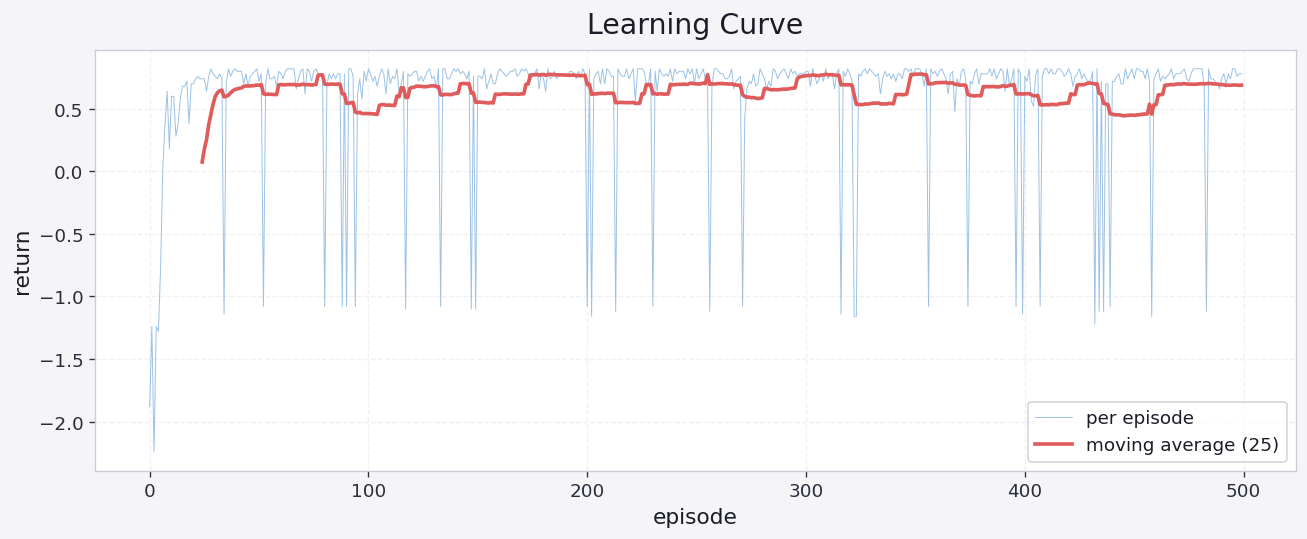

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(rewards, color=C0, lw=0.6, alpha=0.6, label='per episode')
w = 25
ax.plot(np.arange(w-1, len(rewards)), np.convolve(rewards, np.ones(w)/w, 'valid'),
        color=C1, lw=2.2, label=f'moving average ({w})')
ax.set_xlabel('episode'); ax.set_ylabel('return')
ax.set_title('Learning Curve', pad=10); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

---
## Effect of Discount $\gamma$

Smaller $\gamma$ → myopic agent that only sees the immediate reward. Larger $\gamma$ → patient agent that propagates future reward farther back.

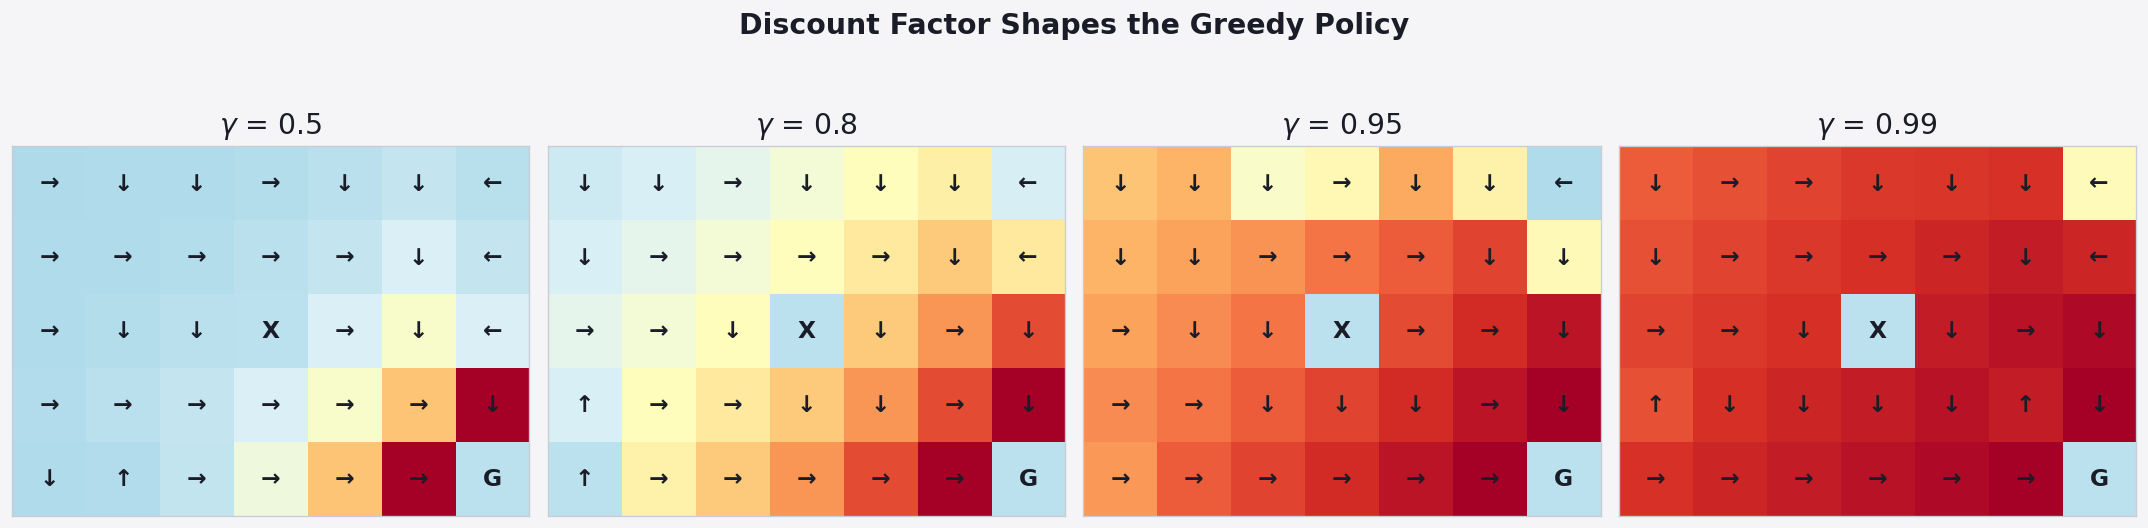

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, g in zip(axes, [0.5, 0.8, 0.95, 0.99]):
    Q, _, _ = train(500, gamma=g, seed=1)
    plot_policy(ax, Q, f'$\\gamma$ = {g}')
fig.suptitle('Discount Factor Shapes the Greedy Policy', fontsize=17, fontweight='bold', y=1.05)
plt.tight_layout(); plt.show()

---
## ⚖️ When to use tabular Q-learning — and when not to

| Situation | Tabular Q-Learning | DQN | Policy Gradient | Model-Based |
|---|---|---|---|---|
| Small, finite state-action space | ✅ | ❌ overkill | partial | ✅ |
| Continuous / huge state space | ❌ table explodes | ✅ | ✅ | partial |
| Deterministic environment | ✅ | ✅ | ✅ | ✅ |
| Need an explicit policy table | ✅ | partial | partial | ✅ |

> Tabular Q-learning is the **clearest demonstration** of off-policy TD learning — use it for teaching and tiny grids.


---
## 🎯 Try this

1. **Exploration schedule.** Replace fixed $\varepsilon$ with $\varepsilon = \max(0.05, 1 - \text{episode}/100)$. Convergence should be cleaner.
2. **SARSA vs Q-Learning.** Switch the update target from $\max_{a'} Q(s', a')$ to $Q(s', a'_\text{next})$. On the cliff-walking problem SARSA finds the safer policy.
3. **Bellman fixed point.** After training, verify $|Q(s,a) - r - \gamma \max_{a'}Q(s',a')|$ is small at every $(s,a)$ — that's the Bellman residual, near zero at convergence.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| $Q(s, a)$ | Expected return from $s$ taking $a$, then optimal | Tabular for finite states |
| Bellman update | $r + \gamma \max Q$ vs current estimate | Off-policy: bootstraps from greedy target |
| Learning rate $\alpha$ | Step size of update | 0.1–0.5 typical |
| Discount $\gamma$ | Weight on future rewards | Closer to 1 → longer horizon |
| $\varepsilon$-greedy | Mix exploration with exploitation | Decay $\varepsilon$ over time |
| Strength | Simple, off-policy, provably converges in tabular case | Foundation for DQN |
| Weakness | Doesn't scale: state space must be enumerable | Use function approx (DQN) for big problems |

**Bottom line:** Q-learning is RL stripped to its essence — a table, a Bellman update, and an $\varepsilon$-greedy walk. Everything fancier (DQN, Double-DQN, Rainbow) is just this idea wearing a neural network.